## Combined CDF plots for HM-Hybrid and DM-Hybrid
from Margo: Put them in a row with a/b/c labels; make the colors of the distribution curves a different set of colors than those for the zone utilization curves; pull the legends out; then have one full width caption that talks about the comparisons bewteen 5 and 7 and the discusses 6 

(although that will then make people wonder why you don't have the different distributions for HMHybrid?)

## Common part and imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

def custom_grouping(index):
    return index // 1000

# names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
# names_latency=['time', 'latency', 'op2', 'write_size', 'op3']
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

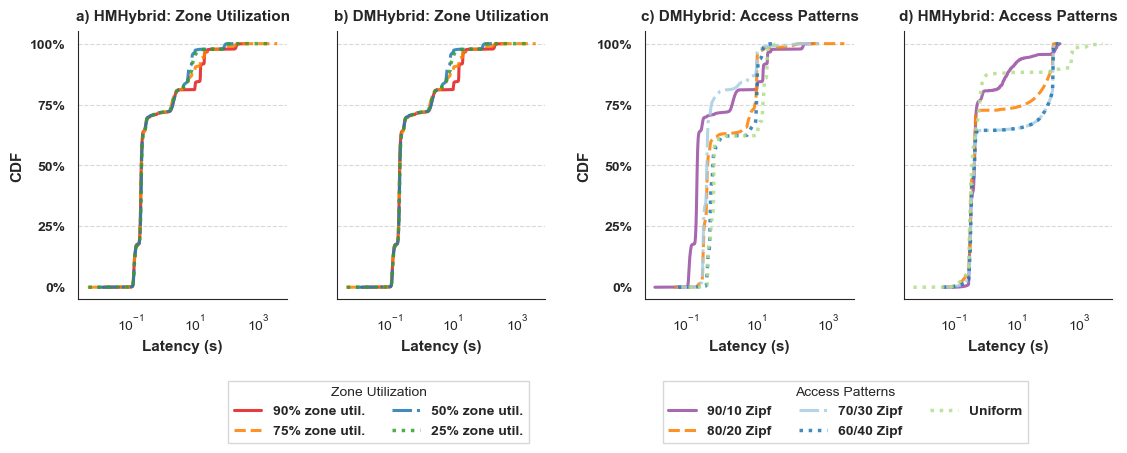

In [ ]:
# Combined CDF plots for HM-Hybrid and DM-Hybrid
# Four plots combined into one figure with shared legend

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

# Create figure with 4 subplots in a row - increase width to accommodate extra spacing
fig_width_pt = 241.02039 * 3.5  # Increased width to accommodate extra spacing
inches_per_pt = 1.0/72.27
golden_mean = (math.sqrt(5)-1.0)/2.0
fig_width = fig_width_pt * inches_per_pt
fig_height = fig_width * golden_mean * 0.5 # Keep same height proportion
fig_size = [fig_width, fig_height]

# Create figure and subplots with proper y-axis sharing
fig, axes = plt.subplots(1, 4, figsize=fig_size)
ax1, ax2, ax3, ax4 = axes

# Share y-axis between ax1 and ax2 (zone utilization plots)
ax2.sharey(ax1)
# Share y-axis between ax3 and ax4 (access pattern plots)
ax4.sharey(ax3)

# Create custom spacing - add extra space between plot 2 and 3
from matplotlib import gridspec
# gs = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 1], 
#                       wspace=0.2)  # Increased wspace for more spacing
gs = gridspec.GridSpec(1, 5, width_ratios=[1, 1, 0.001, 1, 1], wspace=0.3)

# Recreate axes with custom gridspec
for ax in axes:
    ax.remove()

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)
ax3 = fig.add_subplot(gs[3])
ax4 = fig.add_subplot(gs[4], sharey=ax3)

# Adjust spacing
plt.subplots_adjust(top=0.85, bottom=0.2)

# Set up clean styling
sns.set_theme()
sns.set_style("white")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 0.1

# Define different color palettes for different plot types
zone_util_colors = {
    '90%': '#E31A1C',   # Red
    '75%': '#FF7F00',   # Orange  
    '50%': '#1F78B4',   # Blue
    '25%': '#33A02C',   # Green
}

zipf_colors = {
    '9010': '#984EA3',   # Purple
    '8020': '#FF7F00',   # Orange
    '7030': '#A6CEE3',   # Light blue
    '6040': '#1F78B4',   # Blue
    'uniform': '#B2DF8A' # Light green
}

# Common percentile reference lines function
def add_percentile_lines(ax):
    percentiles = [0.25, 0.5, 0.75, 1.0]
    for p in percentiles:
        ax.axhline(y=p, color='gray', linestyle='--', alpha=0.3, linewidth=0.8, zorder=0)

# Common axis formatting
def format_axis(ax, title, xlabel_visible=True, ylabel_visible=True):
    ax.set_xscale('log', base=10)
    ax.grid(False)
    add_percentile_lines(ax)
    
    ytick_positions = [0, 0.25, 0.5, 0.75, 1]
    ytick_labels = ['0%', '25%', '50%', '75%', '100%']
    ax.set_yticks(ytick_positions)
    if ylabel_visible:
        ax.set_yticklabels(ytick_labels, fontsize=10, fontweight='semibold')
    else:
        ax.tick_params(axis='y', labelleft=False)
    ax.tick_params(axis='x', labelsize=10, which='both')
    
    if xlabel_visible:
        ax.set_xlabel('Latency (s)', fontsize=11, fontweight='semibold')
    ax.set_title(title, fontsize=11, fontweight='semibold', pad=8)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

# Plot 1: HMHybrid Performance - Zone Utilization
ax = ax1

# 90% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='-', label="90% zone util.", 
        color=zone_util_colors['90%'], linewidth=2.2, alpha=0.85)

# 75% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/75Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='--', label="75% zone util.", 
        color=zone_util_colors['75%'], linewidth=2.2, alpha=0.85)

# 50% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/50Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='-.', label="50% zone util.", 
        color=zone_util_colors['50%'], linewidth=2.2, alpha=0.85)

# 25% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/25Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle=':', label="25% zone util.", 
        color=zone_util_colors['25%'], linewidth=2.5, alpha=0.85)

format_axis(ax, 'a) HMHybrid: Zone Utilization', ylabel_visible=True)
ax.set_ylabel('CDF', fontsize=11, fontweight='semibold')

# Plot 2: DMHybrid Performance - Zone Utilization  
ax = ax2

# 90% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='-', label="90% zone util.", 
        color=zone_util_colors['90%'], linewidth=2.2, alpha=0.85)

# 75% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/75Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='--', label="75% zone util.", 
        color=zone_util_colors['75%'], linewidth=2.2, alpha=0.85)

# 50% zone utilization  
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/50Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='-.', label="50% zone util.", 
        color=zone_util_colors['50%'], linewidth=2.2, alpha=0.85)

# 25% zone utilization
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/25Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle=':', label="25% zone util.", 
        color=zone_util_colors['25%'], linewidth=2.5, alpha=0.85)

format_axis(ax, 'b) DMHybrid: Zone Utilization', ylabel_visible=False)

# Plot 3: DMHybrid Performance - Access Patterns
ax = ax3

# 90/10 Zipf
df = pd.read_csv('fast2026/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='-', label="90/10 Zipf", 
        color=zipf_colors['9010'], linewidth=2.2, alpha=0.85)

# 80/20 Zipf
df = pd.read_csv('fast2026/STL/1M/80-20-LBA/90Util/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='--', label="80/20 Zipf", 
        color=zipf_colors['8020'], linewidth=2.2, alpha=0.85)

# 70/30 Zipf
df = pd.read_csv('fast2026/STL/1M/70-30-LBA/90Util/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='-.', label="70/30 Zipf", 
        color=zipf_colors['7030'], linewidth=2.2, alpha=0.85)

# 60/40 Zipf
df = pd.read_csv('fast2026/STL/1M/60-40-LBA/90Util/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle=':', label="60/40 Zipf", 
        color=zipf_colors['6040'], linewidth=2.5, alpha=0.85)

# Uniform
df = pd.read_csv('fast2026/STL/1M/uniform/new/uniform/90Util/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle=':', label="Uniform", 
        color=zipf_colors['uniform'], linewidth=2.5, alpha=0.85)

format_axis(ax, 'c) DMHybrid: Access Patterns', ylabel_visible=True)
ax.set_ylabel('CDF', fontsize=11, fontweight='semibold')

# Plot 4: HMHybrid Performance - Access Patterns
ax = ax4

# 90/10 Zipf
df = pd.read_csv('fast2026/HM-Hybrid/1M/90-10-LBA/90Util/round1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='-', label="90/10 Zipf", 
        color=zipf_colors['9010'], linewidth=2.2, alpha=0.85)

# 80/20 Zipf
df = pd.read_csv('fast2026/HM-Hybrid/1M/80-20-LBA/1M/25Util/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='--', label="80/20 Zipf", 
        color=zipf_colors['8020'], linewidth=2.2, alpha=0.85)

# 70/30 Zipf
df = pd.read_csv('fast2026/HM-Hybrid/1M/70-30-LBA/90Util/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle='-.', label="70/30 Zipf", 
        color=zipf_colors['7030'], linewidth=2.2, alpha=0.85)

# 60/40 Zipf (using 70/30 data as placeholder)
df = pd.read_csv('fast2026/HM-Hybrid/1M/70-30-LBA/90Util/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle=':', label="60/40 Zipf", 
        color=zipf_colors['6040'], linewidth=2.5, alpha=0.85)

# Uniform
df = pd.read_csv('fast2026/HM-Hybrid/1M/uniform/90Util/round1/lat_log_avg_lat.1.log', 
                 names=names_latency, usecols=columns)
df['duration'] = df['duration']/1e9
data_sorted = np.sort(df['duration'])
cdf = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
ax.plot(data_sorted, cdf, linestyle=':', label="Uniform", 
        color=zipf_colors['uniform'], linewidth=2.5, alpha=0.85)

format_axis(ax, 'd) HMHybrid: Access Patterns', ylabel_visible=False)

# Create shared legends - one for each type of comparison
# Zone utilization legend (for plots a and b)
zone_util_handles = []
zone_util_labels = []
for line in ax1.get_lines():
    if not line.get_label().startswith('_'):  # Filter out _child labels
        zone_util_handles.append(line)
        zone_util_labels.append(line.get_label())

# Access pattern legend (for plots c and d) 
access_handles = []
access_labels = []
for line in ax3.get_lines():
    if not line.get_label().startswith('_'):  # Filter out _child labels
        access_handles.append(line)
        access_labels.append(line.get_label())

# Keep same legend placement - side by side layout
legend1 = fig.legend(zone_util_handles, zone_util_labels, 
                    loc='upper center', bbox_to_anchor=(0.35, 0.02), 
                    ncol=2, prop={'size': 10, 'weight': 'semibold'},
                    frameon=True, fancybox=False, shadow=False, 
                    framealpha=0.9, edgecolor='lightgray',
                    title='Zone Utilization', title_fontsize=10)

legend2 = fig.legend(access_handles, access_labels,
                    loc='upper center', bbox_to_anchor=(0.7, 0.02), 
                    ncol=3, prop={'size': 10, 'weight': 'semibold'},
                    frameon=True, fancybox=False, shadow=False,
                    framealpha=0.9, edgecolor='lightgray', 
                    title='Access Patterns', title_fontsize=10)

# Save the combined figure
plt.savefig("/Users/Puneet89/Documents/smr_paper/figures/Combined_CDF_1MB_Analysis.pdf", 
            bbox_inches='tight', dpi=600, facecolor='white')
plt.show()

### Read HM-Hybrid data